# Step 5b: Fairness Audit of Retrieval (RQ1)

**Inputs**
- `retrieval_results.json` (Step 5a)
- Institution labels (Step 1b) — Kaggle dataset `fairsearch-qbio-institution-labels`
- elite base rate ~= 23.3% (1,643 / 7,061).

**Metrics**
- **SPD** = retrieved_elite_share - corpus_elite_share  (0 = parity; >0 = elite over-retrieved)
- **SRR** = (retrieved_elite_share / corpus_elite_share) / (retrieved_other_share / corpus_other_share)  (ideal = 1.0)
- Bootstrap 95% CI (resampling over queries) + one-sample binomial test.

In [24]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)  # fixed seed for reproducible bootstrap

In [26]:
# Kaggle: `!git clone https://github.com/YanBoChen0928/FairSearch-qBio.git`

RETRIEVAL_PATH = next(p for p in [
    '../data/processed/retrieval_results.json',
    'FairSearch-qBio/data/processed/retrieval_results.json',
] if os.path.exists(p))
OUT_DIR = os.path.dirname(RETRIEVAL_PATH)

# Step 1b labels (Raj) — pulled via kagglehub in Section 2.
KAGGLE_DATASET = 'rajlucka/fairsearch-qbio-institution-labels'
LABEL_FILE = 'qbio_institution_labels.json'

# ---- Label schema (from Step 1b) ---------------------------------------
# Columns: paper_id, elite_label (1=elite, 0=other, NaN=unlabeled),
#          institution, region (ISO country code), coverage.
CONFIG = {
    'paper_id_col': 'paper_id',
    'is_elite_col': 'elite_label',  # 1.0 -> elite, 0.0 -> other, NaN -> unlabeled
    'region_col':   'region',       # ISO country code (US, FR, GB, ...)
}
K = 10  # top-K used in Step 5a

In [28]:
#load data

with open(RETRIEVAL_PATH) as f:
    retrieval = json.load(f)
print(f'Loaded {len(retrieval)} queries from {RETRIEVAL_PATH}')
print('Keys:', list(retrieval[0].keys()))
assert all(len(q['retrieved_paper_ids']) == K for q in retrieval), 'expected top-K per query'

Loaded 50 queries from ../data/processed/retrieval_results.json
Keys: ['query_id', 'query_text', 'subcategory', 'retrieved_paper_ids', 'relevance', 'precision_at_10', 'recall_at_10', 'hit_rate_at_10']


In [29]:
import kagglehub
kh_path = kagglehub.dataset_download(KAGGLE_DATASET)
labels_df = pd.read_json(os.path.join(kh_path, LABEL_FILE))
print(f'Loaded {len(labels_df):,} label rows | columns: {list(labels_df.columns)}')
labels_df.head(10)

Loaded 55,300 label rows | columns: ['paper_id', 'elite_label', 'institution', 'region', 'coverage']


,paper_id,elite_label,institution,region,coverage
0,0704.0021,0.0,Fritz Haber Institute of the Max Planck Society,DE,found
1,0704.0034,NaN,None,None,no_affiliation
2,0704.0036,NaN,None,None,no_affiliation
3,0704.0158,0.0,Beijing University of Technology,CN,found
4,0704.0191,1.0,Massachusetts Institute of Technology,US,found
5,0704.0271,0.0,Universidade Federal Fluminense,BR,found
6,0704.0304,0.0,Vrije Universiteit Brussel,BE,found
7,0704.0322,0.0,North University of China,CN,found
8,0704.0331,0.0,Centre National de la Recherche Scientifique,FR,found
9,0704.0357,0.0,Eötvös Loránd University,HU,found


In [31]:
# normalize labels

def build_group_map(df, cfg):
    pid, col = cfg['paper_id_col'], cfg['is_elite_col']
    g = {}
    for _, row in df.iterrows():
        val = row.get(col)
        # NaN -> unlabeled (no affiliation found); otherwise 1=elite, 0=other
        if pd.isna(val):
            grp = 'unlabeled'
        else:
            grp = 'elite' if float(val) == 1.0 else 'other'
        g[str(row[pid])] = grp
    return g

group_map = build_group_map(labels_df, CONFIG)
from collections import Counter
corpus_counts = Counter(group_map.values())
print('Corpus label distribution:', dict(corpus_counts))

# Corpus reference rates over the LABELED subset (elite + other)
n_labeled_corpus = corpus_counts['elite'] + corpus_counts['other']
corpus_elite_share = corpus_counts['elite'] / n_labeled_corpus
corpus_other_share = corpus_counts['other'] / n_labeled_corpus
print(f'Labeled corpus = {n_labeled_corpus:,} | elite base rate = {corpus_elite_share:.3f} '
      f'(expected 0.233 per Step 1b)')

Corpus label distribution: {'other': 5418, 'unlabeled': 48239, 'elite': 1643}
Labeled corpus = 7,061 | elite base rate = 0.233 (expected 0.233 per Step 1b)


In [33]:
#coverage check

rows = []
for q in retrieval:
    for rank, pid in enumerate(q['retrieved_paper_ids']):
        grp = group_map.get(str(pid), 'unlabeled')
        rel = q['relevance'][rank] if 'relevance' in q else None
        rows.append({'query_id': q['query_id'], 'subcategory': q['subcategory'],
                     'rank': rank, 'paper_id': pid, 'group': grp, 'relevance': rel})
slots = pd.DataFrame(rows)

n_total   = len(slots)
n_elite   = (slots.group == 'elite').sum()
n_other   = (slots.group == 'other').sum()
n_labeled = n_elite + n_other
n_unlab   = (slots.group == 'unlabeled').sum()

print(f'Total retrieval slots : {n_total}')
print(f'Labeled (elite+other) : {n_labeled}  ({n_labeled/n_total:.1%})')
print(f'  - elite             : {n_elite}')
print(f'  - other             : {n_other}')
print(f'Unlabeled (excluded)  : {n_unlab}  ({n_unlab/n_total:.1%})')
print()

Total retrieval slots : 500
Labeled (elite+other) : 95  (19.0%)
  - elite             : 26
  - other             : 69
Unlabeled (excluded)  : 405  (81.0%)



In [35]:
# SPD & SRR

lab = slots[slots.group.isin(['elite', 'other'])]
e = (lab.group == 'elite').sum()
n = len(lab)
retrieved_elite_share = e / n
retrieved_other_share = 1 - retrieved_elite_share

SPD = retrieved_elite_share - corpus_elite_share
# SRR: over-representation lift of elite vs other; ideal = 1.0
SRR = (retrieved_elite_share / corpus_elite_share) / (retrieved_other_share / corpus_other_share)

print(f'Retrieved elite share : {retrieved_elite_share:.3f}  ({e}/{n})')
print(f'Corpus elite share    : {corpus_elite_share:.3f}')
print(f'SPD                    : {SPD:+.3f}   (>0 => elite over-retrieved)')
print(f'SRR                    : {SRR:.3f}')

Retrieved elite share : 0.274  (26/95)
Corpus elite share    : 0.233
SPD                    : +0.041   (>0 => elite over-retrieved)
SRR                    : 1.243


In [38]:
# uncertainty: bootstrap CI (resample queries) + binomial test

def pooled_metrics(query_subset):
    sub = slots[slots.query_id.isin(query_subset) & slots.group.isin(['elite','other'])]
    if len(sub) == 0:
        return np.nan, np.nan
    es = (sub.group == 'elite').mean()
    spd = es - corpus_elite_share
    srr = (es / corpus_elite_share) / ((1-es) / corpus_other_share) if 0 < es < 1 else np.nan
    return spd, srr

qids = [q['query_id'] for q in retrieval]
B = 5000
boot_spd, boot_srr = [], []
for _ in range(B):
    sample = rng.choice(qids, size=len(qids), replace=True)
    spd, srr = pooled_metrics(sample)
    boot_spd.append(spd); boot_srr.append(srr)
boot_spd = np.array(boot_spd); boot_srr = np.array(boot_srr)

spd_ci = np.nanpercentile(boot_spd, [2.5, 97.5])
srr_ci = np.nanpercentile(boot_srr, [2.5, 97.5])
print(f'SPD 95% CI: [{spd_ci[0]:+.3f}, {spd_ci[1]:+.3f}]')
print(f'SRR 95% CI: [{srr_ci[0]:.3f}, {srr_ci[1]:.3f}]')

# One-sample binomial test: is retrieved elite count different from base rate?
bt = stats.binomtest(int(e), int(n), p=corpus_elite_share, alternative='two-sided')
print(f'Binomial test p-value (H0: elite share == {corpus_elite_share:.3f}): {bt.pvalue:.4f}')
sig = 'SIGNIFICANT' if bt.pvalue < 0.05 else 'not significant'
print(f'-> {sig} at alpha=0.05')

SPD 95% CI: [-0.025, +0.107]
SRR 95% CI: [0.864, 1.696]
Binomial test p-value (H0: elite share == 0.233): 0.3332
-> not significant at alpha=0.05


In [40]:
rel = slots[(slots.group.isin(['elite','other'])) & (slots.relevance == 1)]
if len(rel) >= 10:
    e_r = (rel.group == 'elite').sum(); n_r = len(rel)
    es_r = e_r / n_r
    spd_r = es_r - corpus_elite_share
    srr_r = (es_r/corpus_elite_share) / ((1-es_r)/corpus_other_share) if 0 < es_r < 1 else np.nan
    print(f'Relevant labeled slots: {n_r} (elite={e_r})')
    print(f'SPD (relevant only): {spd_r:+.3f} | SRR: {srr_r:.3f}')

Relevant labeled slots: 65 (elite=18)
SPD (relevant only): +0.044 | SRR: 1.263


In [41]:
if CONFIG.get('region_col') and CONFIG['region_col'] in labels_df.columns:
    region_map = {str(r[CONFIG['paper_id_col']]): r[CONFIG['region_col']]
                  for _, r in labels_df.iterrows()}
    slots['region'] = slots.paper_id.map(lambda p: region_map.get(str(p)))
    reg = slots[slots.group.isin(['elite','other'])].dropna(subset=['region'])
    print('Retrieved labeled papers by region:')
    print(reg.region.value_counts())
    print()
    print('Elite share within each region (descriptive):')
    print(reg.groupby('region').apply(lambda d: (d.group=='elite').mean()).round(3))

Retrieved labeled papers by region:
region
US    31
FR    12
GB    10
DE     7
IL     4
NL     3
IN     3
CH     3
JP     3
ES     2
CN     2
AU     2
HU     2
IT     2
AT     2
TR     1
BR     1
BE     1
PT     1
CA     1
SI     1
CL     1
Name: count, dtype: int64

Elite share within each region (descriptive):
region
AT    0.000
AU    0.500
BE    0.000
BR    0.000
CA    0.000
CH    1.000
CL    0.000
CN    1.000
DE    0.000
ES    0.000
FR    0.000
GB    0.800
HU    0.000
IL    0.000
IN    0.000
IT    0.000
JP    0.000
NL    0.000
PT    0.000
SI    0.000
TR    0.000
US    0.387
dtype: float64


In [42]:
def subcat_row(d):
    lab_d = d[d.group.isin(['elite','other'])]
    n_l = len(lab_d); e_l = (lab_d.group=='elite').sum()
    es = e_l/n_l if n_l else np.nan
    return pd.Series({'labeled': n_l, 'elite': e_l,
                      'elite_share': round(es,3) if n_l else np.nan})
by_sub = slots.groupby('subcategory').apply(subcat_row).sort_values('labeled', ascending=False)
print(by_sub)
print('\nNote: most subcategories have very few labeled slots; read directionally only.')

             labeled  elite  elite_share
subcategory                             
q-bio.QM        16.0    3.0        0.188
q-bio.BM        13.0    5.0        0.385
q-bio.PE        13.0    4.0        0.308
q-bio.MN        11.0    3.0        0.273
q-bio.SC        11.0    2.0        0.182
q-bio.GN        10.0    2.0        0.200
q-bio.TO         6.0    4.0        0.667
q-bio.CB         5.0    2.0        0.400
q-bio.NC         5.0    0.0        0.000
q-bio.OT         5.0    1.0        0.200

Note: most subcategories have very few labeled slots; read directionally only.


In [43]:
summary = {
    'k': K,
    'n_queries': len(retrieval),
    'n_slots_total': int(n_total),
    'n_labeled': int(n_labeled),
    'n_elite': int(n_elite),
    'n_other': int(n_other),
    'n_unlabeled': int(n_unlab),
    'corpus_elite_share': round(float(corpus_elite_share), 4),
    'retrieved_elite_share': round(float(retrieved_elite_share), 4),
    'SPD': round(float(SPD), 4),
    'SRR': round(float(SRR), 4),
    'SPD_95CI': [round(float(spd_ci[0]),4), round(float(spd_ci[1]),4)],
    'SRR_95CI': [round(float(srr_ci[0]),4), round(float(srr_ci[1]),4)],
    'binomial_p': round(float(bt.pvalue), 4),
}
per_query = []
for q in retrieval:
    sub = slots[slots.query_id == q['query_id']]
    labq = sub[sub.group.isin(['elite','other'])]
    per_query.append({
        'query_id': q['query_id'],
        'subcategory': q['subcategory'],
        'n_labeled': int(len(labq)),
        'n_elite': int((labq.group=='elite').sum()),
        'n_other': int((labq.group=='other').sum()),
    })
out = {'summary': summary, 'per_query': per_query}
os.makedirs(OUT_DIR, exist_ok=True)
out_path = os.path.join(OUT_DIR, 'fairness_results.json')
with open(out_path, 'w') as f:
    json.dump(out, f, indent=2)
print('saved to', out_path)
print(json.dumps(summary, indent=2))

saved to ../data/processed/fairness_results.json
{
  "k": 10,
  "n_queries": 50,
  "n_slots_total": 500,
  "n_labeled": 95,
  "n_elite": 26,
  "n_other": 69,
  "n_unlabeled": 405,
  "corpus_elite_share": 0.2327,
  "retrieved_elite_share": 0.2737,
  "SPD": 0.041,
  "SRR": 1.2426,
  "SPD_95CI": [
    -0.0251,
    0.1069
  ],
  "SRR_95CI": [
    0.8637,
    1.6959
  ],
  "binomial_p": 0.3332
}


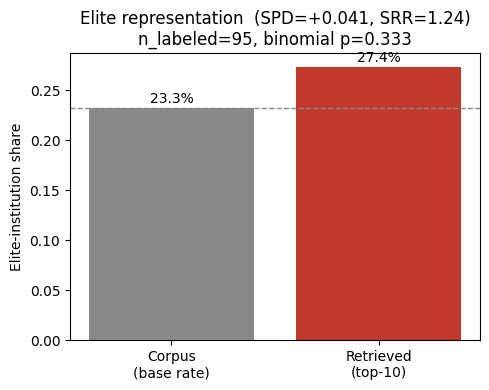

In [44]:
#plot

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Corpus\n(base rate)', 'Retrieved\n(top-%d)' % K],
              [corpus_elite_share, retrieved_elite_share],
              color=['#888', '#c0392b'])
ax.axhline(corpus_elite_share, ls='--', c='#888', lw=1)
ax.set_ylabel('Elite-institution share')
ax.set_title(f'Elite representation  (SPD={SPD:+.3f}, SRR={SRR:.2f})\n'
             f'n_labeled={n_labeled}, binomial p={bt.pvalue:.3f}')
for b, v in zip(bars, [corpus_elite_share, retrieved_elite_share]):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.1%}', ha='center')
plt.tight_layout()
plt.savefig('step5b_elite_share.png', dpi=120)
plt.show()